In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [32]:
df = pd.read_csv('../0.dataset/dataset_karyawan_1000.csv')
df.head(5)

,ID_Karyawan,Jenis_Kelamin,Departemen,Status_Pernikahan,Pendidikan_Terakhir,Level_Jabatan,Rating_Kinerja
0,EMP-0001,Laki-laki,IT,Belum Menikah,S1,Mid-Level,Baik
1,EMP-0002,Perempuan,Finance,Belum Menikah,S1,Senior,Baik
2,EMP-0003,Perempuan,Operations,Menikah,D3,Senior,Sangat Baik
3,EMP-0004,Perempuan,Marketing,Belum Menikah,S1,Junior,Baik
4,EMP-0005,Laki-laki,Operations,Belum Menikah,S1,Junior,Sangat Baik


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Karyawan          1000 non-null   object
 1   Jenis_Kelamin        1000 non-null   object
 2   Departemen           1000 non-null   object
 3   Status_Pernikahan    1000 non-null   object
 4   Pendidikan_Terakhir  1000 non-null   object
 5   Level_Jabatan        1000 non-null   object
 6   Rating_Kinerja       1000 non-null   object
dtypes: object(7)
memory usage: 54.8+ KB


In [34]:
df.shape

(1000, 7)

In [35]:
df.isnull().sum()

ID_Karyawan            0
Jenis_Kelamin          0
Departemen             0
Status_Pernikahan      0
Pendidikan_Terakhir    0
Level_Jabatan          0
Rating_Kinerja         0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df=df.drop(columns='ID_Karyawan')
df.shape

(1000, 6)

In [38]:
target_column = 'Rating_Kinerja'
feature_categori = df.drop(columns='Rating_Kinerja')


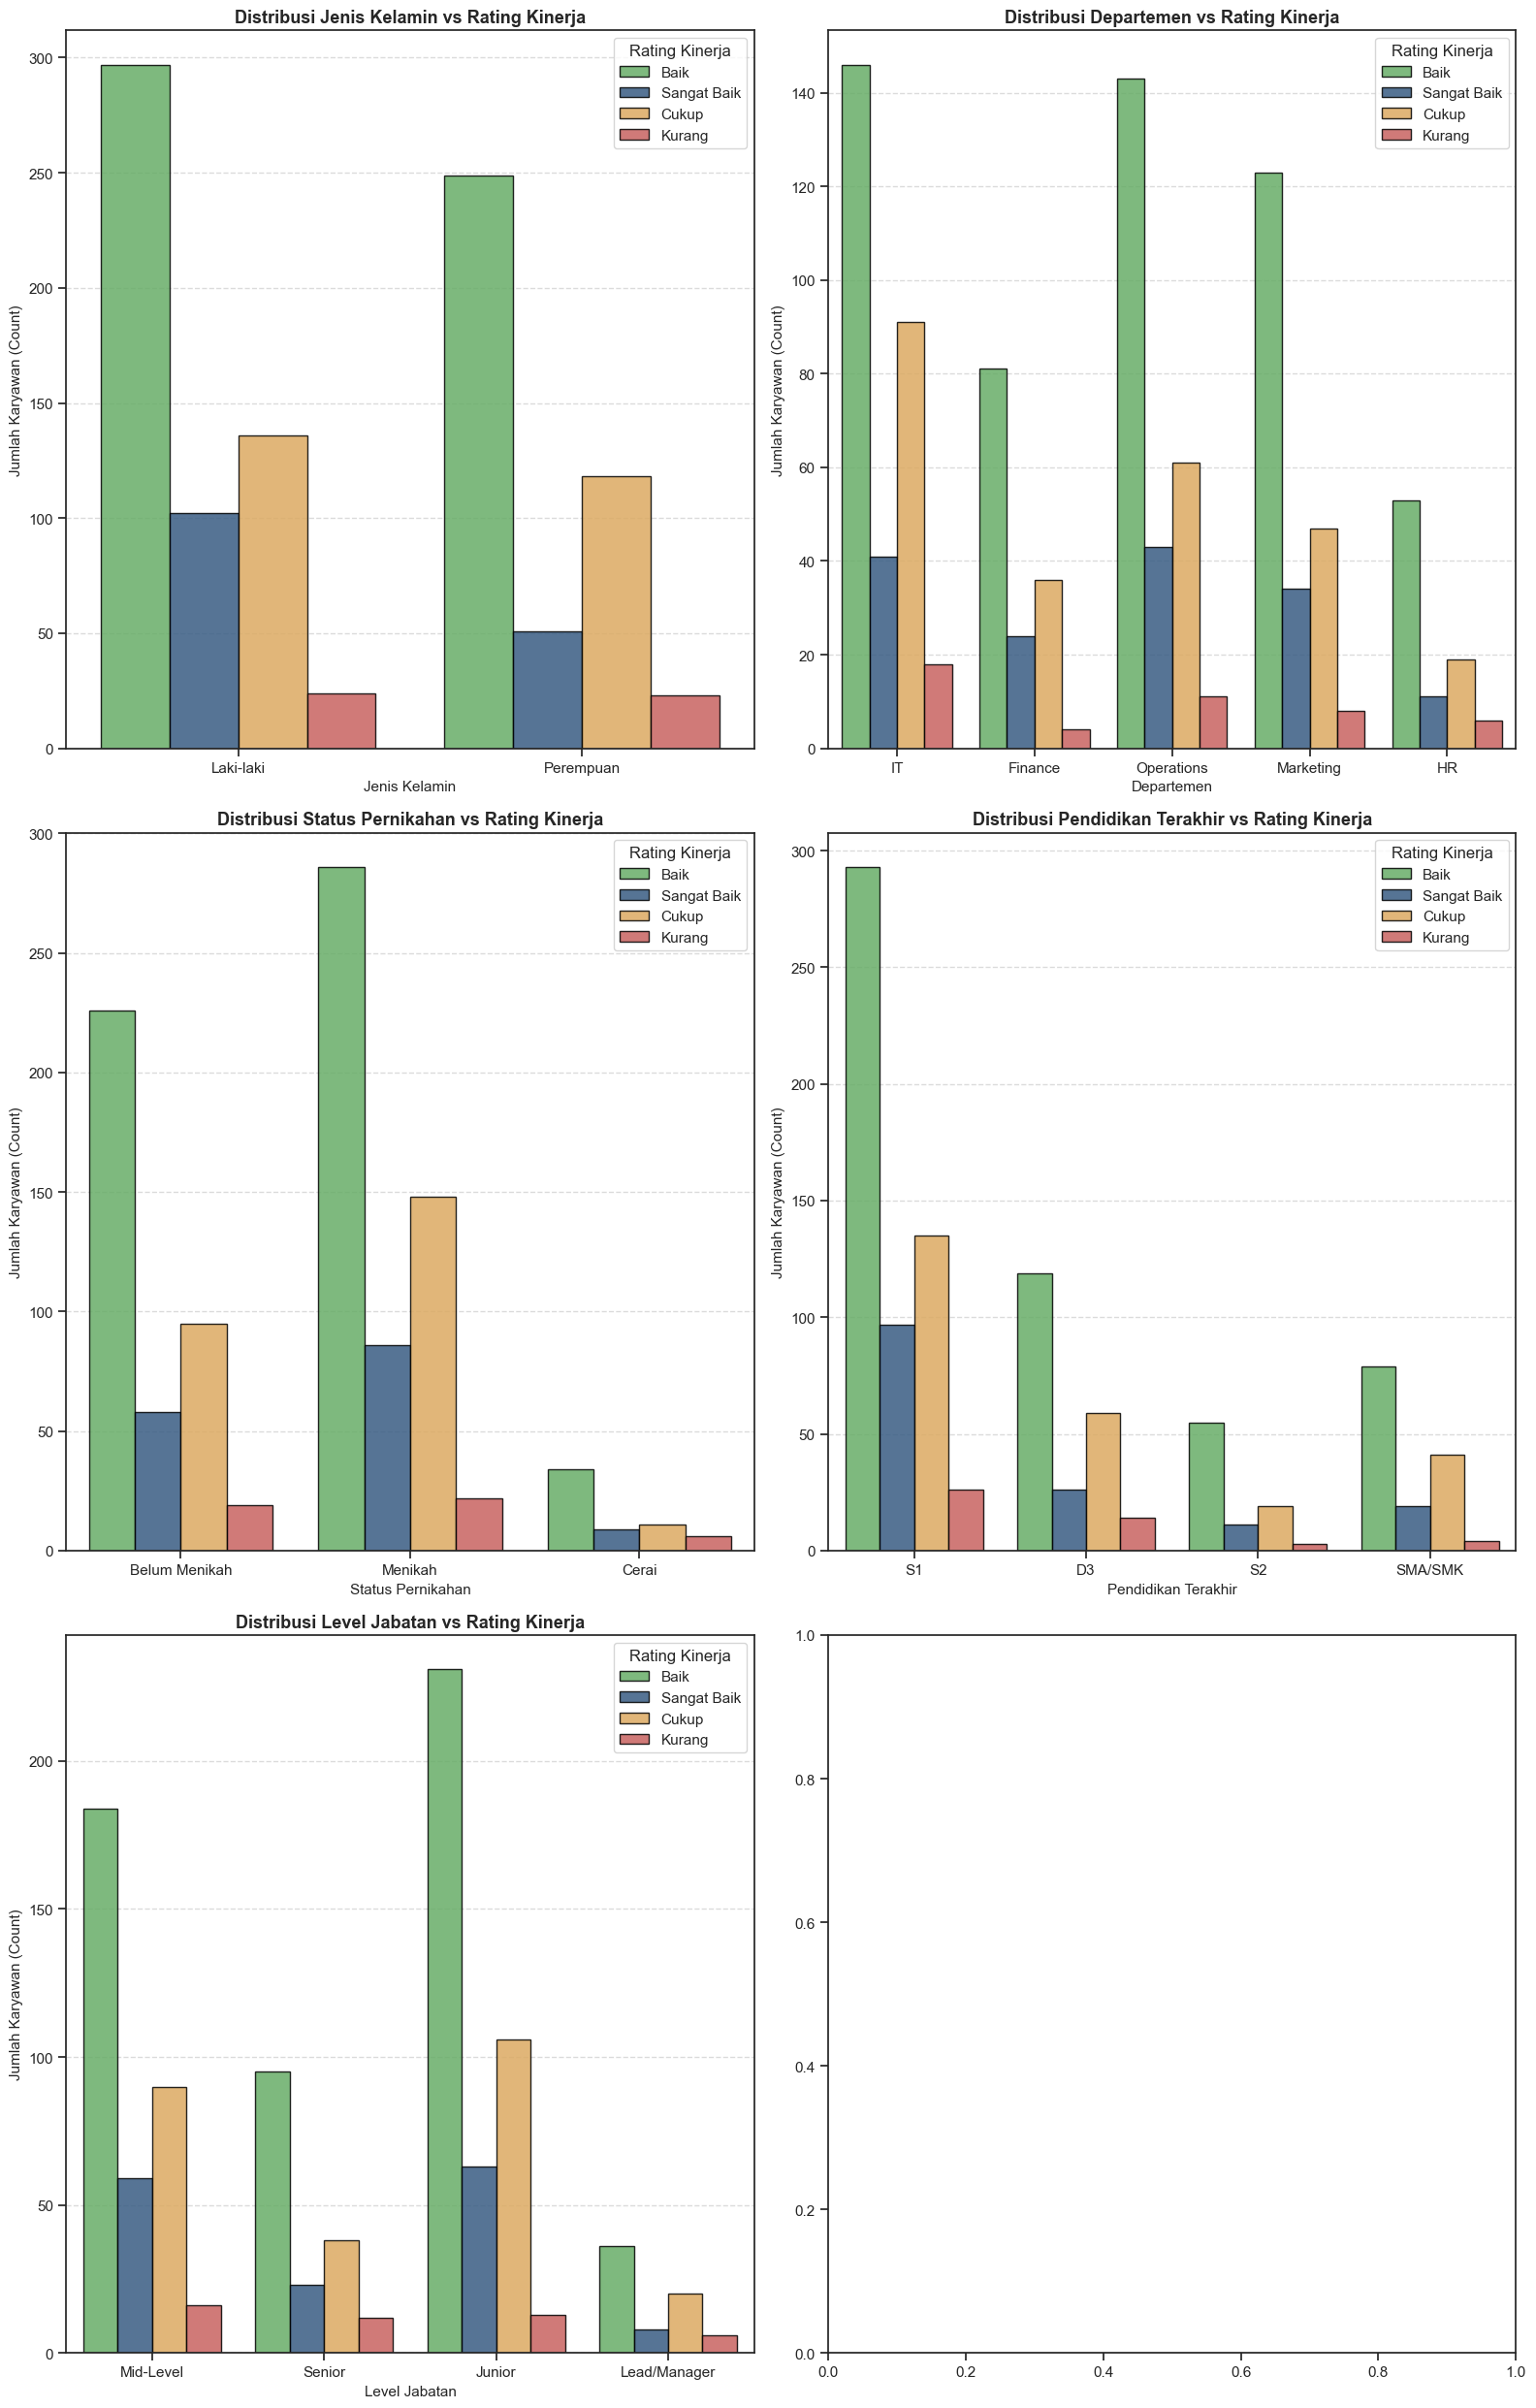

In [39]:
sns.set_theme(style="ticks")
fig, axes = plt.subplots(3, 2, figsize=(16, 25))
axes = axes.flatten()
colors = {
    "Sangat Baik": "#2b5c8f",  # Biru
    "Baik": "#5cb85c",         # Hijau
    "Cukup": "#f0ad4e",        # Kuning/Oranye
    "Kurang": "#d9534f"        # Merah
}
for i, feature in enumerate(feature_categori):
    sns.countplot(data=df,x=feature,hue=target_column,ax=axes[i],palette=colors,edgecolor="black",alpha=0.85)
    # Kustomisasi setiap grafik
    axes[i].set_title(f"Distribusi {feature.replace('_', ' ')} vs {target_column.replace('_', ' ')}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel(feature.replace('_', ' '), fontsize=11)
    axes[i].set_ylabel("Jumlah Karyawan (Count)", fontsize=11)
    axes[i].legend(title="Rating Kinerja", loc='upper right')
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

# 5. Menyembunyikan subplot ke-6 (indeks 5) karena kita hanya punya 5 fitur
if len(feature_categori) < len(axes):
    axes[-1].set_visible(False)

# Mengatur tata letak agar rapi dan menampilkan grafik
plt.tight_layout()
plt.show()

## Feauture Engineering

In [40]:
def menetukan_ekonomi(row):
    pendidikan = row['Pendidikan_Terakhir']
    jabatan = row['Level_Jabatan']
    kinerja = row['Rating_Kinerja']

    if jabatan == 'Senior' or (jabatan == 'Mid-Level' and pendidikan == 'S2'):
        return 'Keatas'
    elif (jabatan == 'Junior' and pendidikan == 'D3') or kinerja == 'Kurang':
        return 'Kebawah'
    else:
        return 'Menengah'
    
df['Status_Ekonomi'] = df.apply(menetukan_ekonomi,axis=1)
df.head()

,Jenis_Kelamin,Departemen,Status_Pernikahan,Pendidikan_Terakhir,Level_Jabatan,Rating_Kinerja,Status_Ekonomi
0,Laki-laki,IT,Belum Menikah,S1,Mid-Level,Baik,Menengah
1,Perempuan,Finance,Belum Menikah,S1,Senior,Baik,Keatas
2,Perempuan,Operations,Menikah,D3,Senior,Sangat Baik,Keatas
3,Perempuan,Marketing,Belum Menikah,S1,Junior,Baik,Menengah
4,Laki-laki,Operations,Belum Menikah,S1,Junior,Sangat Baik,Menengah


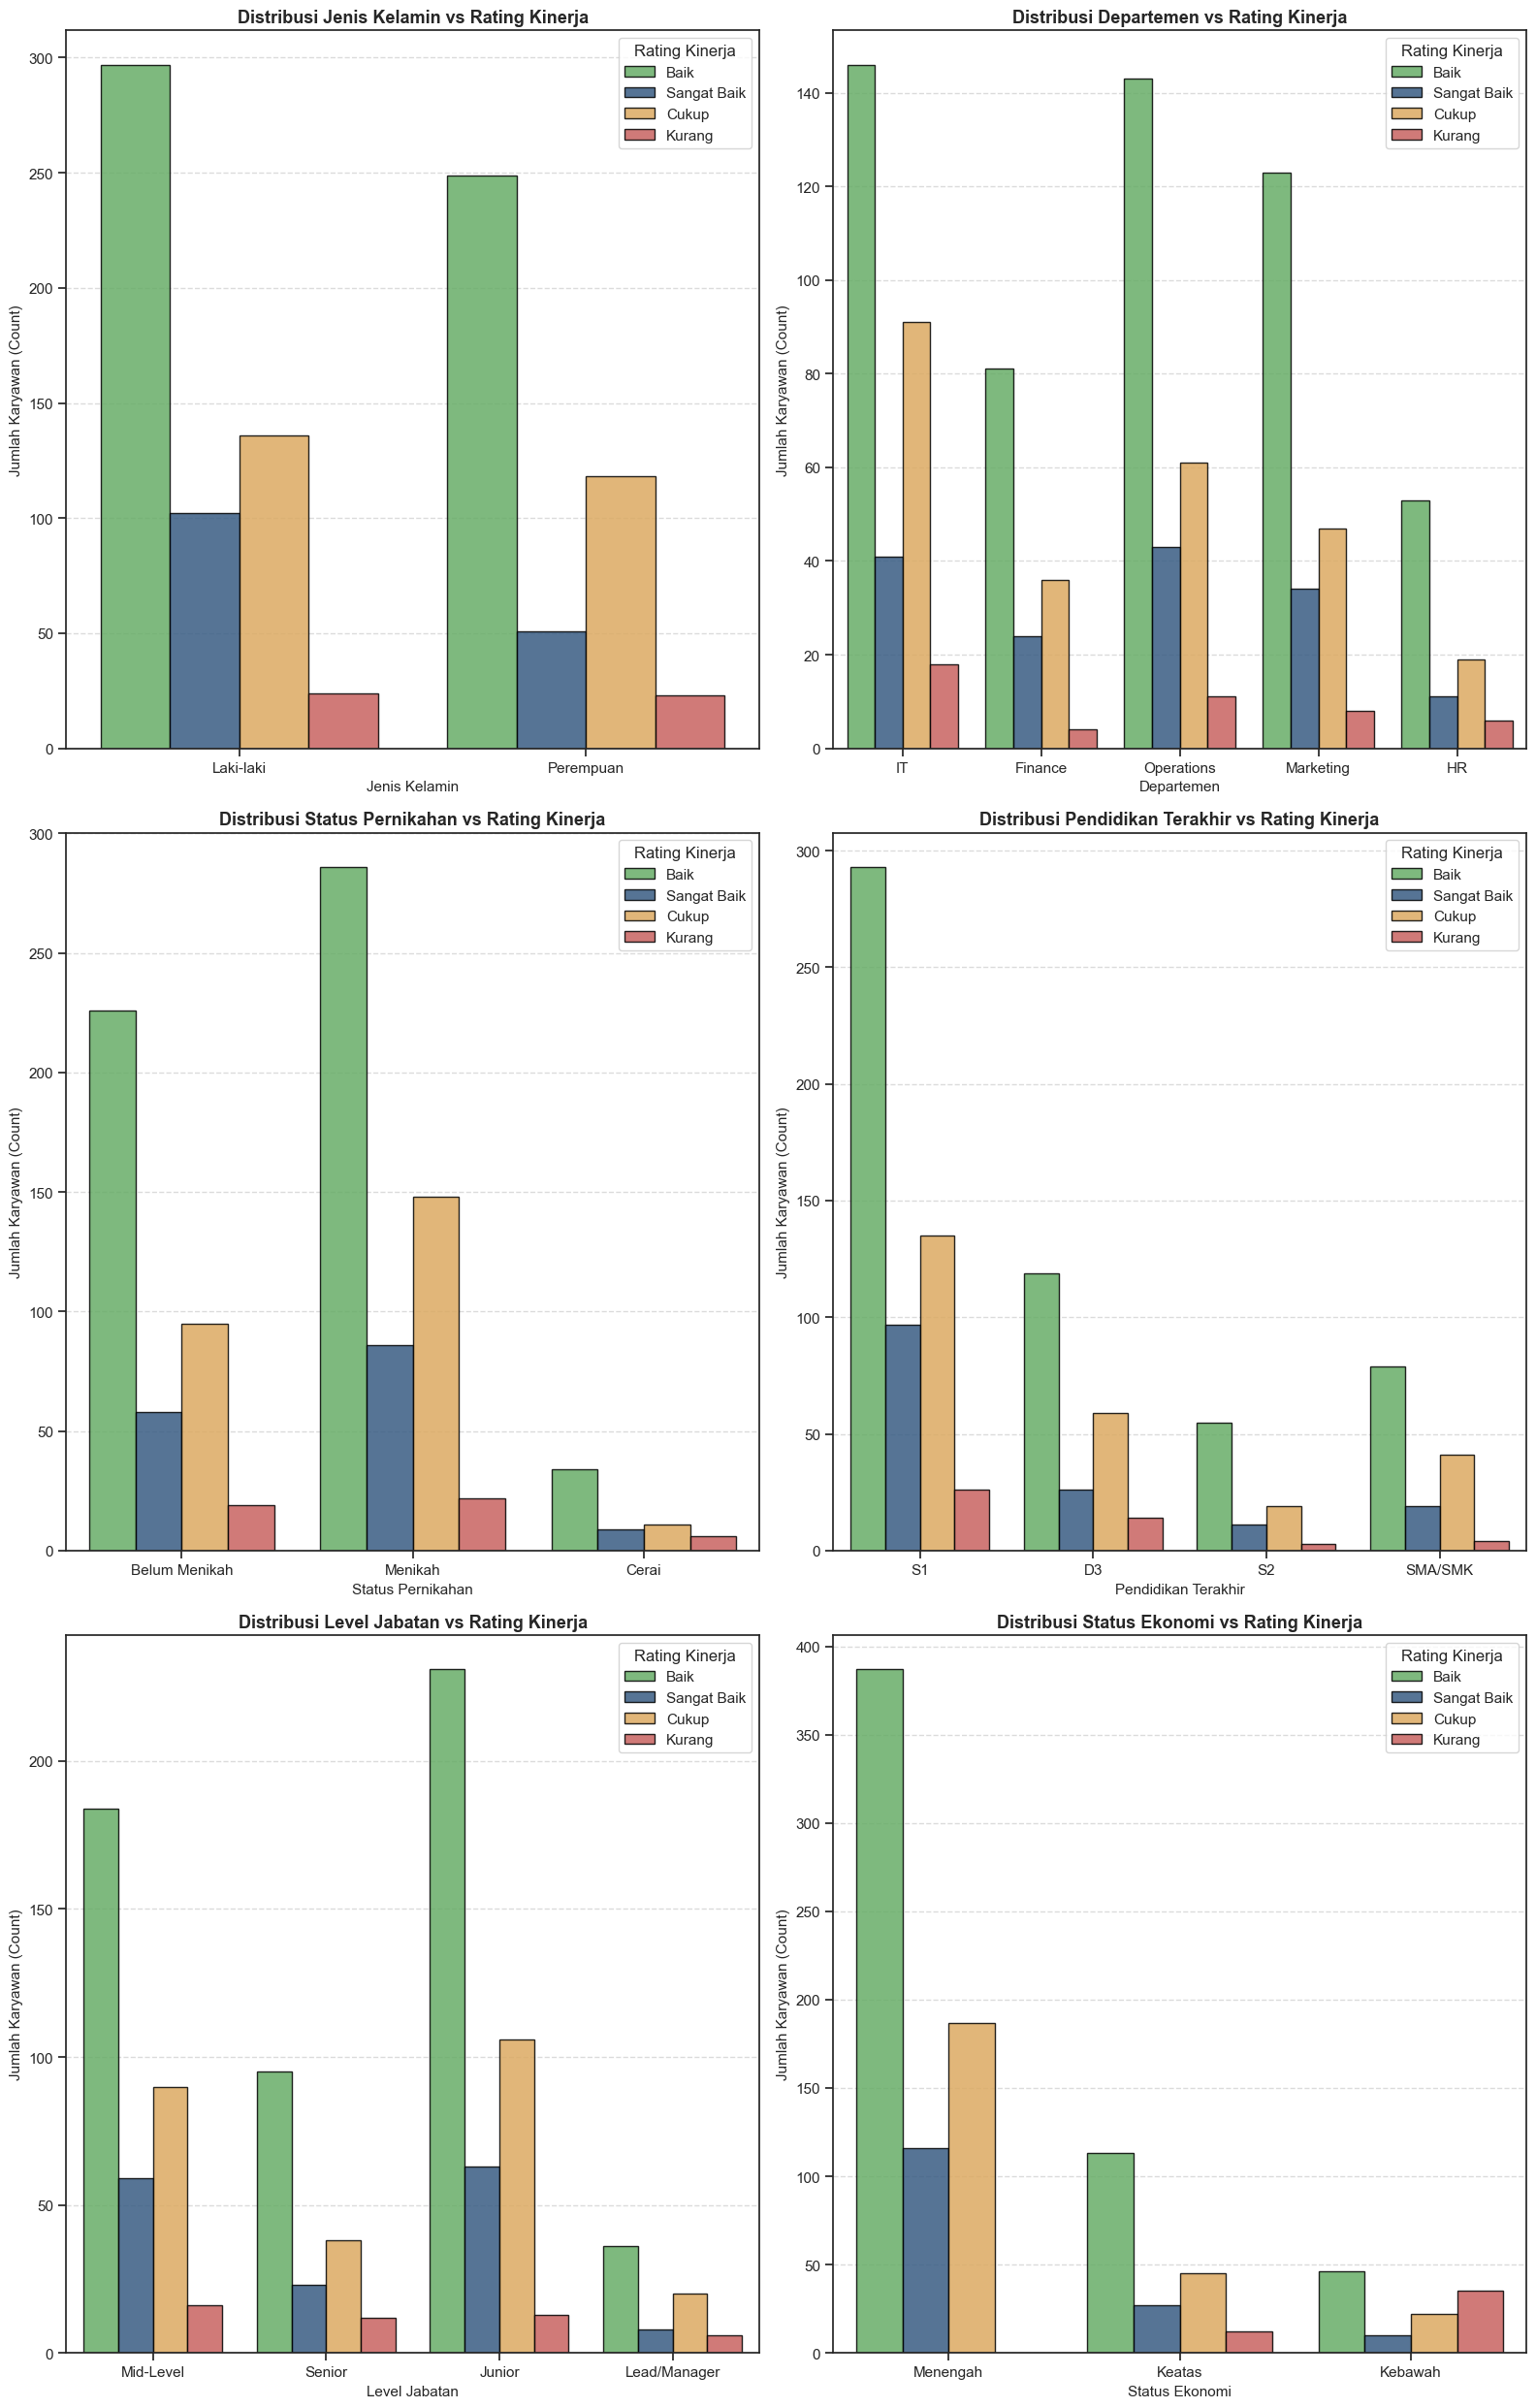

In [41]:
feature_categori = df.drop(columns='Rating_Kinerja')
sns.set_theme(style="ticks")
fig, axes = plt.subplots(3, 2, figsize=(16, 25))
axes = axes.flatten()
colors = {
    "Sangat Baik": "#2b5c8f",  # Biru
    "Baik": "#5cb85c",         # Hijau
    "Cukup": "#f0ad4e",        # Kuning/Oranye
    "Kurang": "#d9534f"        # Merah
}
for i, feature in enumerate(feature_categori):
    sns.countplot(data=df,x=feature,hue=target_column,ax=axes[i],palette=colors,edgecolor="black",alpha=0.85)
    # Kustomisasi setiap grafik
    axes[i].set_title(f"Distribusi {feature.replace('_', ' ')} vs {target_column.replace('_', ' ')}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel(feature.replace('_', ' '), fontsize=11)
    axes[i].set_ylabel("Jumlah Karyawan (Count)", fontsize=11)
    axes[i].legend(title="Rating Kinerja", loc='upper right')
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

# 5. Menyembunyikan subplot ke-6 (indeks 5) karena kita hanya punya 5 fitur
if len(feature_categori) < len(axes):
    axes[-1].set_visible(False)

# Mengatur tata letak agar rapi dan menampilkan grafik
plt.tight_layout()
plt.show()

In [42]:
colom_ordinal = ['Pendidikan_Terakhir','Level_Jabatan','Rating_Kinerja','Status_Ekonomi']
colom_nominal = ['Jenis_Kelamin','Departemen','Status_Pernikahan']

In [44]:
urutan_pendidikan = ['SMA/SMK','D3','S1','S2']
urutan_jabatan = ['Mid-Level','Junior','Senior','Lead/Manager']
urutan_kinerja = ['Kurang','Cukup','Baik','Sangat Baik']
urutan_ekonomi = ['Kebawah','Menengah','Keatas']

ordinal = OrdinalEncoder(categories=[urutan_pendidikan,urutan_jabatan,urutan_kinerja,urutan_ekonomi],dtype=int)
df[colom_ordinal] = ordinal.fit_transform(df[colom_ordinal])
df.head()


,Jenis_Kelamin,Departemen,Status_Pernikahan,Pendidikan_Terakhir,Level_Jabatan,Rating_Kinerja,Status_Ekonomi
0,Laki-laki,IT,Belum Menikah,2,0,2,1
1,Perempuan,Finance,Belum Menikah,2,2,2,2
2,Perempuan,Operations,Menikah,1,2,3,2
3,Perempuan,Marketing,Belum Menikah,2,1,2,1
4,Laki-laki,Operations,Belum Menikah,2,1,3,1


In [45]:
label = LabelEncoder()
for col in df[colom_nominal].columns:
    df[col] = label.fit_transform(df[col])
df.head()

,Jenis_Kelamin,Departemen,Status_Pernikahan,Pendidikan_Terakhir,Level_Jabatan,Rating_Kinerja,Status_Ekonomi
0,0,2,0,2,0,2,1
1,1,0,0,2,2,2,2
2,1,4,2,1,2,3,2
3,1,3,0,2,1,2,1
4,0,4,0,2,1,3,1


In [46]:
df.to_csv("dataset_Kinerja_Karyawan_clean.csv", index=False)
# df.head()